In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
samiradli_carhoods10k_3d_point_cloud_and_parametric_dataset_path = kagglehub.dataset_download('samiradli/carhoods10k-3d-point-cloud-and-parametric-dataset')

print('Data source import complete.')


In [ ]:
import h5py
import numpy as np
import plotly.graph_objects as go
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [ ]:
h5_path = '/kaggle/input/datasets/samiradli/carhoods10k-3d-point-cloud-and-parametric-dataset/CarHoods_Extracted.h5'

# Pick any row index between 0 and 9981 to visualize
sample_idx = 9980

# 1. Extract the data for this specific hood
with h5py.File(h5_path, 'r') as hf:
    points = hf['points'][sample_idx]
    stress = hf['stress'][sample_idx]
    mass = hf['mass'][sample_idx]
    deform = hf['deformation'][sample_idx]

# 2. Separate into X, Y, Z arrays
x = points[:, 0]
y = points[:, 1]
z = points[:, 2]

# 3. Build the interactive 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=1.5,
        color=z,                # Color the points based on their Z-height
        colorscale='Viridis',
        opacity=0.8
    )
)])

# 4. Clean up the layout and set the aspect ratio
fig.update_layout(
    title=f"Sample #{sample_idx} | Stress: {stress:.2f} | Mass: {mass:.2f} | Deform: {deform:.2f}",
    scene=dict(
        xaxis=dict(visible=False), # Hiding the grid lines makes the shape clearer
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode='data'          # Locks the aspect ratio so the car hood isn't stretched
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

# Render the plot
fig.show()

In [ ]:
# Get PyTorch and CUDA versions
torch_version = torch.__version__.split('+')[0]
cuda_version = torch.version.cuda.replace('.', '')

print(f"Installing PyG for PyTorch {torch_version} and CUDA {cuda_version}...")

# Download the pre-compiled C++ operations
os.system(f"pip install torch-scatter torch-cluster -f https://data.pyg.org/whl/torch-{torch_version}+cu{cuda_version}.html")
os.system("pip install torch-geometric")

print("PyTorch Geometric installed successfully.")

Installing PyG for PyTorch 2.9.0 and CUDA 126...
Looking in links: https://data.pyg.org/whl/torch-2.9.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 67.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 59.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.2 MB/s eta 0:00:00
PyTorch Geometric installed successfully.


In [ ]:
# PyG Imports
import torch_geometric
import torch_geometric.typing
from torch_geometric.nn import fps, global_max_pool, PointNetConv
from torch_cluster import radius

Loading data for visualization...
Stress Outliers: 9
Mass Outliers: 0
Deform Outliers: 1


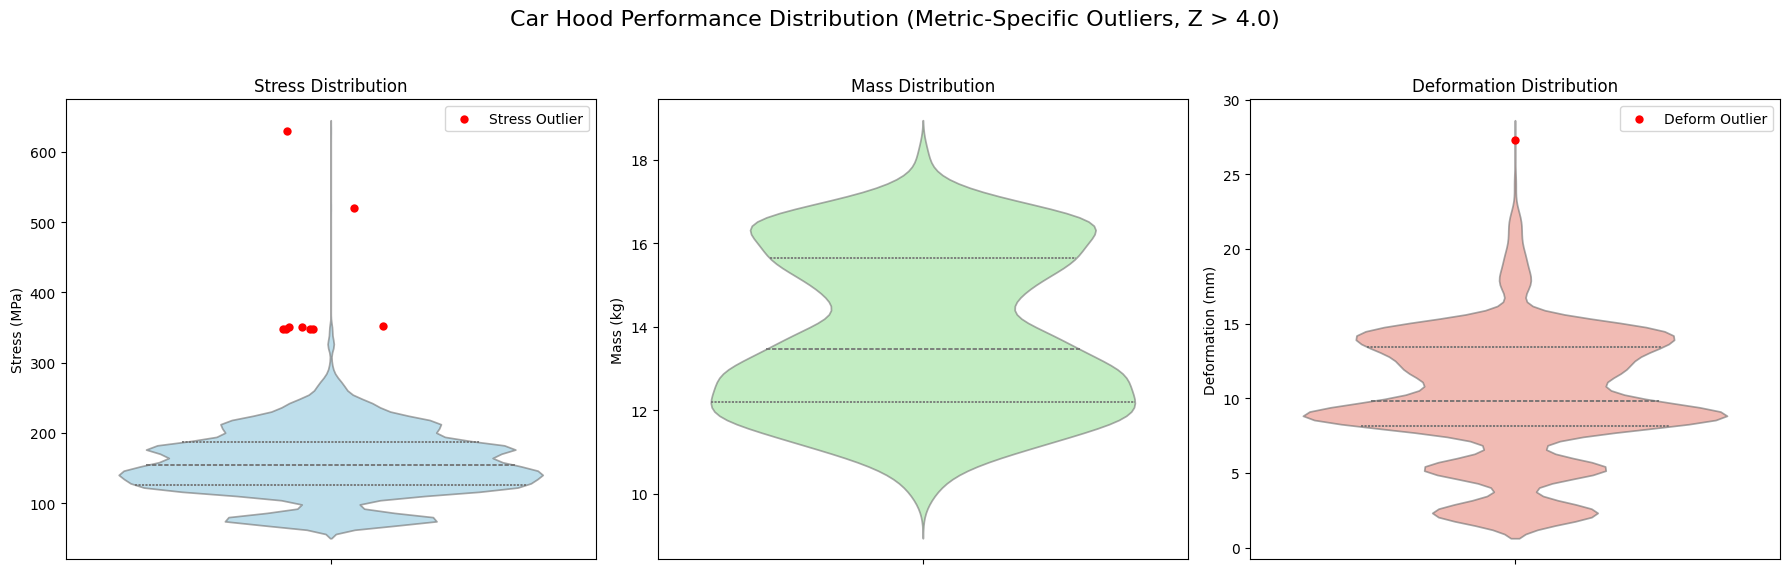

In [ ]:
# Visulazing outliers
input_path = '/kaggle/input/datasets/samiradli/carhoods10k-3d-point-cloud-and-parametric-dataset/CarHoods_Extracted.h5'
Z_THRESHOLD = 4.0

print("Loading data for visualization...")
with h5py.File(input_path, 'r') as hf_in:
    stress = hf_in['stress'][:]
    mass = hf_in['mass'][:]
    deform = hf_in['deformation'][:]

# 1. Calculate Mean and Standard Deviation
stress_mean, stress_std = np.mean(stress), np.std(stress)
mass_mean, mass_std = np.mean(mass), np.std(mass)
deform_mean, deform_std = np.mean(deform), np.std(deform)

# 2. Create DataFrame and calculate specific Z-Scores
df = pd.DataFrame({
    'Stress (MPa)': stress.flatten(),
    'Mass (kg)': mass.flatten(),
    'Deformation (mm)': deform.flatten()
})

df['Z_Stress'] = np.abs((df['Stress (MPa)'] - stress_mean) / stress_std)
df['Z_Mass'] = np.abs((df['Mass (kg)'] - mass_mean) / mass_std)
df['Z_Deform'] = np.abs((df['Deformation (mm)'] - deform_mean) / deform_std)

print(f"Stress Outliers: {len(df[df['Z_Stress'] >= Z_THRESHOLD])}")
print(f"Mass Outliers: {len(df[df['Z_Mass'] >= Z_THRESHOLD])}")
print(f"Deform Outliers: {len(df[df['Z_Deform'] >= Z_THRESHOLD])}")

# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Car Hood Performance Distribution (Metric-Specific Outliers, Z > {Z_THRESHOLD})', fontsize=16)

# Plot 1: Stress
sns.violinplot(data=df, y='Stress (MPa)', ax=axes[0], color="skyblue", inner="quartile", alpha=0.6)
# Only plot dots that are outliers SPECIFICALLY in Stress
sns.stripplot(data=df[df['Z_Stress'] >= Z_THRESHOLD], y='Stress (MPa)', ax=axes[0], color='red', size=6, jitter=True, label='Stress Outlier')
axes[0].set_title('Stress Distribution')

# Plot 2: Mass
sns.violinplot(data=df, y='Mass (kg)', ax=axes[1], color="lightgreen", inner="quartile", alpha=0.6)
# Only plot dots that are outliers SPECIFICALLY in Mass
sns.stripplot(data=df[df['Z_Mass'] >= Z_THRESHOLD], y='Mass (kg)', ax=axes[1], color='red', size=6, jitter=True, label='Mass Outlier')
axes[1].set_title('Mass Distribution')

# Plot 3: Deformation
sns.violinplot(data=df, y='Deformation (mm)', ax=axes[2], color="salmon", inner="quartile", alpha=0.6)
# Only plot dots that are outliers SPECIFICALLY in Deformation
sns.stripplot(data=df[df['Z_Deform'] >= Z_THRESHOLD], y='Deformation (mm)', ax=axes[2], color='red', size=6, jitter=True, label='Deform Outlier')
axes[2].set_title('Deformation Distribution')

# Clean up legends
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles[-1:], labels[-1:], loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import h5py
import numpy as np

# File paths
input_path = '/kaggle/input/datasets/samiradli/carhoods10k-3d-point-cloud-and-parametric-dataset/CarHoods_Extracted.h5'
clean_path = '/kaggle/working/CarHoods_NoOutliers.h5'

# We will use Z=4.0. This means we only delete a car hood if its stress, mass,
# or deformation is more than 4 standard deviations away from the average.
Z_THRESHOLD = 4.0

print("Scanning for outliers...")

with h5py.File(input_path, 'r') as hf_in:
    # 1. Load targets into memory
    stress = hf_in['stress'][:]
    mass = hf_in['mass'][:]
    deform = hf_in['deformation'][:]

    # 2. Calculate Mean and Standard Deviation for each
    stress_mean, stress_std = np.mean(stress), np.std(stress)
    mass_mean, mass_std = np.mean(mass), np.std(mass)
    deform_mean, deform_std = np.mean(deform), np.std(deform)

    # 3. Calculate Z-Scores (absolute values)
    z_stress = np.abs((stress - stress_mean) / stress_std)
    z_mass = np.abs((mass - mass_mean) / mass_std)
    z_deform = np.abs((deform - deform_mean) / deform_std)

    # 4. Find the row indices where ALL targets are within the threshold
    # (If even one target is an outlier, we throw out the whole car hood)
    valid_indices = np.where(
        (z_stress < Z_THRESHOLD) &
        (z_mass < Z_THRESHOLD) &
        (z_deform < Z_THRESHOLD)
    )[0]

    total_hoods = len(stress)
    valid_hoods = len(valid_indices)
    outliers_removed = total_hoods - valid_hoods

    print(f"\n--- OUTLIER REPORT ---")
    print(f"Total starting hoods: {total_hoods}")
    print(f"Outliers found & removed: {outliers_removed}")
    print(f"Clean hoods remaining: {valid_hoods}")

    # 5. Write the clean data to a new file
    print(f"\nWriting clean data to {clean_path}...")
    with h5py.File(clean_path, 'w') as hf_out:
        # Copy metadata attributes
        for attr_name, attr_val in hf_in.attrs.items():
            hf_out.attrs[attr_name] = attr_val

        # Copy over only the valid rows for every dataset
        for key in hf_in.keys():
            print(f"  -> Filtering and saving {key}...")
            data = hf_in[key][:]
            hf_out.create_dataset(key, data=data[valid_indices])

print(f"\nOutlier-free dataset is ready.")

Scanning for outliers...

--- OUTLIER REPORT ---
Total starting hoods: 9982
Outliers found & removed: 10
Clean hoods remaining: 9972

Writing clean data to /kaggle/working/CarHoods_NoOutliers.h5...
  -> Filtering and saving deformation...
  -> Filtering and saving design_parameters...
  -> Filtering and saving mass...
  -> Filtering and saving points...
  -> Filtering and saving stress...

Outlier-free dataset is ready.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware: {device}")

Hardware: cuda


In [ ]:
# ==========================================
# 1. NORMALIZED DATASET & DETERMINISTIC SPLIT
# ==========================================
class NormalizedCarHoodDataset(Dataset):
    def __init__(self, h5_path):
        print("Loading and scaling dataset...")
        with h5py.File(h5_path, 'r') as hf:
            self.points = hf['points'][:]
            self.params = hf['design_parameters'][:]
            self.stress = hf['stress'][:]
            self.mass = hf['mass'][:]
            self.deformation = hf['deformation'][:]

        # 1. Centering at origin
        centroid = np.mean(self.points, axis=1, keepdims=True)
        self.points = self.points - centroid

        # 2. Scaling to unit sphere
        dist = np.linalg.norm(self.points, axis=2, keepdims=True)
        max_dist = np.max(dist, axis=1, keepdims=True)
        self.points = self.points / (max_dist + 1e-8)

        self.length = self.points.shape[0]

        # Normalize CAD Parameters
        self.params_mean = np.mean(self.params, axis=0)
        self.params_std = np.std(self.params, axis=0) + 1e-8
        self.params_normalized = (self.params - self.params_mean) / self.params_std

        # Normalize Targets
        self.targets = np.column_stack((self.stress, self.mass, self.deformation))
        self.targets_mean = np.mean(self.targets, axis=0)
        self.targets_std = np.std(self.targets, axis=0) + 1e-8
        self.targets_normalized = (self.targets - self.targets_mean) / self.targets_std
        print("Done.")

    def __len__(self): return self.length

    def __getitem__(self, idx):
        # Initial point cloud shape
        pts = self.points[idx]

        # --- DOWNSAMPLING ---
        # Reduce point density to (2048, 3)
        step = pts.shape[0] // 2048
        pts = pts[::step][:2048]
        # --------------------

        points_tensor = torch.tensor(pts, dtype=torch.float32).transpose(0, 1)
        params_tensor = torch.tensor(self.params_normalized[idx], dtype=torch.float32)
        targets_tensor = torch.tensor(self.targets_normalized[idx], dtype=torch.float32)
        return points_tensor, params_tensor, targets_tensor

    def inverse_transform_targets(self, normalized_preds_tensor):
        preds_np = normalized_preds_tensor.cpu().detach().numpy()
        return (preds_np * self.targets_std) + self.targets_mean


# Initialize Dataset
full_dataset = NormalizedCarHoodDataset('/kaggle/working/CarHoods_NoOutliers.h5')
train_size = int(0.85 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Deterministic Seeding for Dataset Split
SEED = 40
torch.manual_seed(SEED)
np.random.seed(SEED)
generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

# Configuration for multi-GPU / high VRAM
BATCH_SIZE = 64
NUM_WORKERS = 4

# Fallback configuration for single GPU / lower VRAM
# BATCH_SIZE = 32
# NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

Loading and scaling dataset...
Done.


In [ ]:
# ==========================================
# 2. MODEL ARCHITECTURE
# ==========================================
class SAModule(nn.Module):
    def __init__(self, ratio, r, nn_structure):
        super(SAModule, self).__init__()
        self.ratio, self.r = ratio, r
        self.conv = PointNetConv(local_nn=nn_structure, add_self_loops=False)

    def forward(self, x, pos, batch):
        idx = fps(pos, batch, ratio=self.ratio)
        row, col = radius(pos, pos[idx], self.r, batch, batch[idx], max_num_neighbors=64)
        edge_index = torch.stack([col, row], dim=0)
        x_dst = None if x is None else x[idx]
        x = self.conv((x, x_dst), (pos, pos[idx]), edge_index)
        pos, batch = pos[idx], batch[idx]
        return x, pos, batch

class PointNetPlusPlusExtractor(nn.Module):
    def __init__(self, output_dim=256):
        super(PointNetPlusPlusExtractor, self).__init__()

        # Set momentum=0.01 for stable running statistics
        self.sa1_mlp = nn.Sequential(
            nn.Linear(3, 32), nn.ReLU(), nn.BatchNorm1d(32, momentum=0.01),
            nn.Linear(32, 64), nn.ReLU(), nn.BatchNorm1d(64, momentum=0.01)
        )
        self.sa1 = SAModule(ratio=0.125, r=0.1, nn_structure=self.sa1_mlp)

        self.sa2_mlp = nn.Sequential(
            nn.Linear(64 + 3, 128), nn.ReLU(), nn.BatchNorm1d(128, momentum=0.01),
            nn.Linear(128, 128), nn.ReLU(), nn.BatchNorm1d(128, momentum=0.01)
        )
        self.sa2 = SAModule(ratio=0.25, r=0.2, nn_structure=self.sa2_mlp)

        self.lin1 = nn.Linear(128, 256)
        self.bn1 = nn.BatchNorm1d(256, momentum=0.01)
        self.lin2 = nn.Linear(256, output_dim)

    def forward(self, points_tensor):
        points_tensor = points_tensor.transpose(1, 2)
        batch_size, num_points, _ = points_tensor.shape
        pos = points_tensor.reshape(-1, 3)
        batch = torch.arange(batch_size, device=pos.device).repeat_interleave(num_points)

        x, pos, batch = self.sa1(None, pos, batch)
        x, pos, batch = self.sa2(x, pos, batch)
        x = global_max_pool(x, batch)
        x = torch.relu(self.bn1(self.lin1(x)))
        return self.lin2(x)

class DualInputPerformanceModel(nn.Module):
    def __init__(self, pointnet_extractor):
        super(DualInputPerformanceModel, self).__init__()
        self.point_features = pointnet_extractor
        self.param_features = nn.Sequential(nn.Linear(54, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU())
        self.fusion_layers = nn.Sequential(nn.Linear(384, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(p=0.3), nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 3))

    def forward(self, points, params):
        geom_feat = self.point_features(points)
        param_feat = self.param_features(params)
        combined_feat = torch.cat((geom_feat, param_feat), dim=1)
        return self.fusion_layers(combined_feat)

In [ ]:
# ==========================================
# 3. TRAINING LOOP
# ==========================================
pn_plus_plus = PointNetPlusPlusExtractor(output_dim=256)
model = DualInputPerformanceModel(pointnet_extractor=pn_plus_plus)

# Multi-GPU Configuration
if torch.cuda.device_count() > 1:
    print(f"Utilizing {torch.cuda.device_count()} GPUs via DataParallel.")
    model = nn.DataParallel(model)

model = model.to(device)

# Fallback Single-GPU Configuration
# model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Reduces learning rate by 50% if validation loss plateaus for 5 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Automatic Mixed Precision (AMP) Scaler
scaler = torch.amp.GradScaler('cuda')

num_epochs = 150
best_val_loss = float('inf')
save_path = '/kaggle/working/CarHood_Best_Weights.pth'

# Early Stopping Configuration
early_stop_patience = 15
epochs_without_improvement = 0

print(f"\nStarting training phase...")
for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0

    for points, params, targets in train_loader:
        points, params, targets = points.to(device), params.to(device), targets.to(device)
        optimizer.zero_grad()

        # Optimized AMP Training Pass
        with torch.amp.autocast('cuda'):
            outputs = model(points, params)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        # Fallback Standard Training Pass (No AMP)
        # outputs = model(points, params)
        # loss = criterion(outputs, targets)
        # loss.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for points, params, targets in val_loader:
            points, params, targets = points.to(device), params.to(device), targets.to(device)

            # Using AMP for inference as well
            with torch.amp.autocast('cuda'):
                outputs = model(points, params)
                loss = criterion(outputs, targets)

            # Fallback Standard Inference Pass
            # outputs = model(points, params)
            # loss = criterion(outputs, targets)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    # Step the learning rate scheduler
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch [{epoch+1:03d}/{num_epochs}] | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    # --- CHECKPOINTING & EARLY STOPPING ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0

        # Handle state_dict saving correctly if DataParallel was used
        model_to_save = model.module if isinstance(model, nn.DataParallel) else model
        torch.save(model_to_save.state_dict(), save_path)

        print(f"    -> New best model saved. (Validation Loss: {best_val_loss:.4f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stop_patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            break

print("\nTraining complete.")

Utilizing 2 GPUs via DataParallel.

Starting training phase...
Epoch [001/150] | LR: 0.001000 | Train Loss: 0.3294 | Val Loss: 1.3999
    -> New best model saved. (Validation Loss: 1.3999)
Epoch [002/150] | LR: 0.001000 | Train Loss: 0.1459 | Val Loss: 1.1947
    -> New best model saved. (Validation Loss: 1.1947)
Epoch [003/150] | LR: 0.001000 | Train Loss: 0.1142 | Val Loss: 0.9762
    -> New best model saved. (Validation Loss: 0.9762)
Epoch [004/150] | LR: 0.001000 | Train Loss: 0.0965 | Val Loss: 0.7944
    -> New best model saved. (Validation Loss: 0.7944)
Epoch [005/150] | LR: 0.001000 | Train Loss: 0.0860 | Val Loss: 0.7269
    -> New best model saved. (Validation Loss: 0.7269)
Epoch [006/150] | LR: 0.001000 | Train Loss: 0.0819 | Val Loss: 0.3591
    -> New best model saved. (Validation Loss: 0.3591)
Epoch [007/150] | LR: 0.001000 | Train Loss: 0.0798 | Val Loss: 0.1186
    -> New best model saved. (Validation Loss: 0.1186)
Epoch [008/150] | LR: 0.001000 | Train Loss: 0.0743 | V

In [ ]:
import torch
import numpy as np

# 1. LOAD YOUR MODEL (Assuming 'model' and 'full_dataset' are in memory)
model.eval()

# 2. THE VERIFICATION FUNCTION
def evaluate_and_rank(subset_dataset, dataset_name, num_samples=50):
    print(f"\nEvaluating {num_samples} random samples from the {dataset_name} Set...")

    # Pick random local indices from this specific subset
    local_indices = np.random.choice(len(subset_dataset), num_samples, replace=False)

    # Grab the ORIGINAL H5 row IDs using the locked Subset indices
    original_h5_ids = [subset_dataset.indices[i] for i in local_indices]

    # Gather data
    points_list, params_list, actuals_list = [], [], []
    for idx in local_indices:
        pts, prms, tgts = subset_dataset[idx]
        points_list.append(pts)
        params_list.append(prms)
        actuals_list.append(tgts)

    # Batch and predict
    points_batch = torch.stack(points_list).to(device)
    params_batch = torch.stack(params_list).to(device)
    actuals_batch = torch.stack(actuals_list).to(device)

    with torch.no_grad():
        preds_batch = model(points_batch, params_batch)

    real_preds = full_dataset.inverse_transform_targets(preds_batch)
    real_actuals = full_dataset.inverse_transform_targets(actuals_batch)

    # Rank them
    results = []
    for i in range(num_samples):
        s_act, m_act, d_act = real_actuals[i]
        s_prd, m_prd, d_prd = real_preds[i]

        s_err = abs(s_act - s_prd)
        m_err = abs(m_act - m_prd)
        d_err = abs(d_act - d_prd)

        s_pct = (s_err / (abs(s_act) + 1e-5)) * 100
        m_pct = (m_err / (abs(m_act) + 1e-5)) * 100
        d_pct = (d_err / (abs(d_act) + 1e-5)) * 100
        total_error_score = s_pct + m_pct + d_pct

        results.append({
            'orig_id': original_h5_ids[i],
            's_act': s_act, 'm_act': m_act, 'd_act': d_act,
            's_prd': s_prd, 'm_prd': m_prd, 'd_prd': d_prd,
            's_err': s_err, 'm_err': m_err, 'd_err': d_err,
            'score': total_error_score
        })

    results.sort(key=lambda x: x['score'])

    # Print Output
    print("\n" + "="*50)
    print(f"🏆 {dataset_name.upper()} SET: TOP 3 BEST")
    print("="*50)
    for i, res in enumerate(results[:3]):
        print(f"\nBest #{i+1} (Original H5 Row ID: {res['orig_id']})")
        print(f"ACTUAL    | Stress: {res['s_act']:.2f} MPa | Mass: {res['m_act']:.2f} kg | Deform: {res['d_act']:.2f} mm")
        print(f"PREDICTED | Stress: {res['s_prd']:.2f} MPa | Mass: {res['m_prd']:.2f} kg | Deform: {res['d_prd']:.2f} mm")
        print(f"ABS ERROR | Stress: {res['s_err']:.2f}     | Mass: {res['m_err']:.2f}    | Deform: {res['d_err']:.2f}")

    print("\n" + "="*50)
    print(f"🚨 {dataset_name.upper()} SET: TOP 3 WORST")
    print("="*50)
    for i, res in enumerate(reversed(results[-3:])):
        print(f"\nWorst #{i+1} (Original H5 Row ID: {res['orig_id']})")
        print(f"ACTUAL    | Stress: {res['s_act']:.2f} MPa | Mass: {res['m_act']:.2f} kg | Deform: {res['d_act']:.2f} mm")
        print(f"PREDICTED | Stress: {res['s_prd']:.2f} MPa | Mass: {res['m_prd']:.2f} kg | Deform: {res['d_prd']:.2f} mm")
        print(f"ABS ERROR | Stress: {res['s_err']:.2f}     | Mass: {res['m_err']:.2f}    | Deform: {res['d_err']:.2f}")

# 3. RUN
evaluate_and_rank(val_dataset, "Validation")


Evaluating 50 random samples from the Validation Set...

🏆 VALIDATION SET: TOP 3 BEST

Best #1 (Original H5 Row ID: 5927)
ACTUAL    | Stress: 220.30 MPa | Mass: 12.63 kg | Deform: 9.29 mm
PREDICTED | Stress: 219.88 MPa | Mass: 12.61 kg | Deform: 9.36 mm
ABS ERROR | Stress: 0.42     | Mass: 0.01    | Deform: 0.06

Best #2 (Original H5 Row ID: 6412)
ACTUAL    | Stress: 162.61 MPa | Mass: 16.74 kg | Deform: 14.42 mm
PREDICTED | Stress: 163.22 MPa | Mass: 16.77 kg | Deform: 14.33 mm
ABS ERROR | Stress: 0.61     | Mass: 0.03    | Deform: 0.09

Best #3 (Original H5 Row ID: 9028)
ACTUAL    | Stress: 213.74 MPa | Mass: 13.44 kg | Deform: 15.11 mm
PREDICTED | Stress: 213.72 MPa | Mass: 13.29 kg | Deform: 15.09 mm
ABS ERROR | Stress: 0.02     | Mass: 0.15    | Deform: 0.02

🚨 VALIDATION SET: TOP 3 WORST

Worst #1 (Original H5 Row ID: 2772)
ACTUAL    | Stress: 303.27 MPa | Mass: 10.47 kg | Deform: 15.05 mm
PREDICTED | Stress: 198.42 MPa | Mass: 10.78 kg | Deform: 14.90 mm
ABS ERROR | Stress: 104

Running full validation set for Parity Plot...


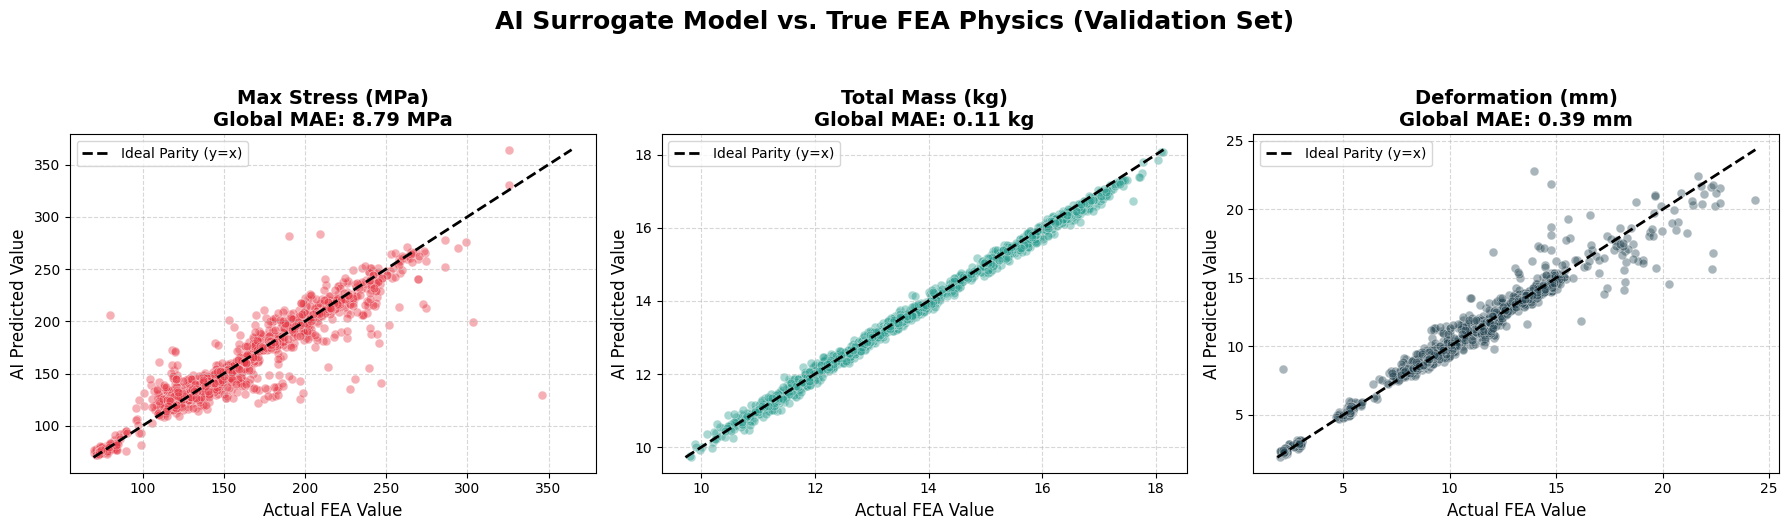

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

# ==========================================
# 1. LOAD WEIGHTS (With Multi-GPU Fix)
# ==========================================
save_path = '/kaggle/working/CarHood_Best_Weights.pth'
state_dict = torch.load(save_path, map_location=device)

# The Smart Loader: Handles Single vs. Multi-GPU states seamlessly
if isinstance(model, nn.DataParallel):
    if not list(state_dict.keys())[0].startswith('module.'):
        model.module.load_state_dict(state_dict)
    else:
        model.load_state_dict(state_dict)
else:
    if list(state_dict.keys())[0].startswith('module.'):
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # Remove 'module.' prefix
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(state_dict)

model.eval()

# ==========================================
# 2. RUN INFERENCE ON VALIDATION SET
# ==========================================
all_actuals = []
all_preds = []

print("Running full validation set for Parity Plot...")

with torch.no_grad():
    for points, params, targets in val_loader:
        points, params = points.to(device), params.to(device)

        # Predict
        normalized_preds = model(points, params)

        # Un-normalize back to MPa, kg, mm
        real_preds = full_dataset.inverse_transform_targets(normalized_preds)
        real_actuals = full_dataset.inverse_transform_targets(targets)

        # Move back to CPU and numpy for plotting
        all_actuals.append(real_actuals)
        all_preds.append(real_preds)

# ==========================================
# 3. CALCULATE METRICS
# ==========================================
# Concatenate all batches into single arrays
all_actuals = np.vstack(all_actuals)
all_preds = np.vstack(all_preds)

# Separate out the 3 targets
actual_stress, actual_mass, actual_deform = all_actuals[:, 0], all_actuals[:, 1], all_actuals[:, 2]
pred_stress, pred_mass, pred_deform = all_preds[:, 0], all_preds[:, 1], all_preds[:, 2]

# Calculate Global Mean Absolute Error (MAE) for the titles
mae_stress = np.mean(np.abs(actual_stress - pred_stress))
mae_mass = np.mean(np.abs(actual_mass - pred_mass))
mae_deform = np.mean(np.abs(actual_deform - pred_deform))

# ==========================================
# 4. GENERATE THE PLOTS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle("AI Surrogate Model vs. True FEA Physics (Validation Set)", fontsize=18, fontweight='bold', y=1.05)

titles = [
    f'Max Stress (MPa)\nGlobal MAE: {mae_stress:.2f} MPa',
    f'Total Mass (kg)\nGlobal MAE: {mae_mass:.2f} kg',
    f'Deformation (mm)\nGlobal MAE: {mae_deform:.2f} mm'
]
actuals_list = [actual_stress, actual_mass, actual_deform]
preds_list = [pred_stress, pred_mass, pred_deform]
colors = ['#E63946', '#2A9D8F', '#264653'] # Red for Stress, Green for Mass, Blue for Deform

for i in range(3):
    ax = axes[i]

    # Scatter plot of all validation samples
    ax.scatter(actuals_list[i], preds_list[i], alpha=0.4, color=colors[i], edgecolors='white', linewidth=0.5, s=40)

    # Parity Line (Perfect Prediction y = x)
    min_val = min(np.min(actuals_list[i]), np.min(preds_list[i]))
    max_val = max(np.max(actuals_list[i]), np.max(preds_list[i]))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Parity (y=x)')

    # Formatting
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel('Actual FEA Value', fontsize=12)
    ax.set_ylabel('AI Predicted Value', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()